# Αξιολόγηση στα external test sets

Δύο διακριτά βήματα, με αυτή τη σειρά:

1. **Βήμα 1 — μόνο training.** Εκπαίδευση και επιλογή του κατωφλιού απόφασης από
   5-fold cross-validation στα 1142 μόρια του Training sheet. Κανένα test set δεν
   φορτώνεται σε αυτό το βήμα.
2. **Βήμα 2 — test set.** Το μοντέλο και το κατώφλι του Βήματος 1 εφαρμόζονται
   αμετάβλητα. Καμία προσαρμογή με βάση τα test δεδομένα.

| cutoff | μοντέλο | OOF ROC-AUC |
|---|---|---|
| 50% | ExtraTrees + CatBoost (soft average) | 0.7727 |
| 20% | ExtraTrees | 0.7721 |

Για να αξιολογήσεις και τα δύο test sets: τρέξε το Βήμα 1 μία φορά, μετά άλλαξε
το `test_set` και ξανατρέξε **μόνο** το Βήμα 2.


In [13]:
# ============================== ΠΑΡΑΜΕΤΡΟΙ ==============================
# Άλλαξε μόνο αυτές τις δύο γραμμές· το μοντέλο επιλέγεται αυτόματα.
test_set   = 'Test set 1'        # 'Test set 1' | 'Test set 2'
label_case = 'label_cutoff_20%'  # 'label_cutoff_50%' | 'label_cutoff_20%'

RANDOM_STATE = 42

# Το μοντέλο ανά σενάριο, όπως προέκυψε από το hyperparameter_tunning_new:
#   cutoff 50%  ->  ExtraTrees + CatBoost  (soft average, OOF ROC-AUC 0.7727)
#   cutoff 20%  ->  ExtraTrees             (μεμονωμένο,   OOF ROC-AUC 0.7721)
MODEL_CHOICE = {
    'label_cutoff_50%': ['ExtraTrees', 'CatBoost'],
    'label_cutoff_20%': ['ExtraTrees'],
}

# Κατώφλι απόφασης. Το 0.5 είναι αυθαίρετο όταν οι κλάσεις είναι ανισόρροπες.
#   0.5          -> σταθερό
#   'cv_youden'  -> από 5-fold CV στα training μόρια, max Youden's J (= max Balanced Accuracy)
#   'cv_mcc'     -> από 5-fold CV στα training μόρια, max MCC
# Τα 'cv_*' υπολογίζονται ΜΟΝΟ στα training δεδομένα — το test set δεν συμμετέχει.
THRESHOLD = {
    'label_cutoff_50%': 'cv_youden',
    'label_cutoff_20%': 'cv_youden',
}


## Βήμα 1 — Εκπαίδευση και επιλογή κατωφλιού (μόνο training δεδομένα)

In [14]:
# ========== ΒΗΜΑ 1 — ΕΚΠΑΙΔΕΥΣΗ ΚΑΙ ΕΠΙΛΟΓΗ ΚΑΤΩΦΛΙΟΥ (μόνο training) ==========
# Σε αυτό το κελί ΔΕΝ φορτώνεται κανένα test set. Ό,τι χρειάζεται το μοντέλο —
# υπερπαράμετροι, εκπαίδευση, κατώφλι απόφασης — προκύπτει αποκλειστικά από τα
# 1142 μόρια του Training sheet.
import os
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import ExtraTreesClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score, roc_curve

TAG = label_case.replace('label_cutoff_', '').replace('%', '')

# ---------------------------------------------------------------- features
_feat_file = next(p for p in [f'../Data/final_dataset_{label_case}.xlsx',
                              '../Data/final_dataset_223.xlsx'] if os.path.exists(p))
features = [c for c in pd.read_excel(_feat_file, sheet_name='Dataset', nrows=1).columns
            if c not in ('SMILES', 'smile')]

# ------------------------------------------------------- δεδομένα εκπαίδευσης
_train_file = next(p for p in [f'../Data/merged_df_clean_{label_case}.csv',
                               '../Data/merged_df_clean.csv'] if os.path.exists(p))
train = pd.read_csv(_train_file)
train = train[train[label_case].notna()]
X_train = train[features]
y_train = train[label_case].astype(int).to_numpy()
medians = X_train.median()          # για τα NaN των test descriptors, από το training

# ------------------------------------------------------------------ μοντέλα
def build(name):
    if name == 'ExtraTrees':
        est = ExtraTreesClassifier(n_estimators=300, max_features='log2',
                                   min_samples_split=5, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)
    elif name == 'CatBoost':
        est = CatBoostClassifier(depth=4, learning_rate=0.15, iterations=300,
                                 random_seed=RANDOM_STATE, verbose=0,
                                 auto_class_weights='Balanced', thread_count=-1)
    else:
        raise ValueError(f'άγνωστο μοντέλο: {name}')
    return Pipeline([('scaler', RobustScaler()), ('model', est)])

members = MODEL_CHOICE[label_case]
MODEL_NAME = ' + '.join(members) + (' (soft average)' if len(members) > 1 else '')

print(f"Σενάριο   : {label_case}")
print(f"Features  : {len(features)}   (από {os.path.basename(_feat_file)})")
print(f"Training  : {len(y_train)} μόρια   (High={int(y_train.sum())}, Low={int((y_train==0).sum())})")
print(f"Μοντέλο   : {MODEL_NAME}\n")

# ------------------------------------------- 1α. out-of-fold πιθανότητες (CV)
_thr_cfg = THRESHOLD[label_case] if isinstance(THRESHOLD, dict) else THRESHOLD

if isinstance(_thr_cfg, str):
    print("Υπολογισμός out-of-fold πιθανοτήτων (5-fold CV στα training μόρια)...")
    _cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    oof_train = np.mean([cross_val_predict(build(n), X_train, y_train, cv=_cv,
                                           method='predict_proba', n_jobs=1)[:, 1]
                         for n in members], axis=0)

    # ------------------------------------------- 1β. το κατώφλι από τις OOF
    if _thr_cfg == 'cv_youden':
        _fpr, _tpr, _t = roc_curve(y_train, oof_train)
        threshold = float(_t[np.argmax(_tpr - _fpr)])
    elif _thr_cfg == 'cv_mcc':
        _grid = np.arange(0.05, 0.96, 0.005)
        threshold = float(_grid[int(np.argmax(
            [matthews_corrcoef(y_train, (oof_train >= v).astype(int)) for v in _grid]))])
    else:
        raise ValueError(f"άγνωστο THRESHOLD: {_thr_cfg}")

    _p05 = (oof_train >= 0.5).astype(int)
    _pth = (oof_train >= threshold).astype(int)
    print(f"\n>>> ΚΑΤΩΦΛΙ = {threshold:.3f}   (κανόνας: {_thr_cfg}, από 5-fold CV)\n")
    print(f"  Επίδοση στα training (OOF):   {'στο 0.500':>12} {'στο ' + format(threshold, '.3f'):>12}")
    print(f"    MCC                         {matthews_corrcoef(y_train, _p05):>12.4f} "
          f"{matthews_corrcoef(y_train, _pth):>12.4f}")
    print(f"    Balanced Accuracy           {balanced_accuracy_score(y_train, _p05):>12.4f} "
          f"{balanced_accuracy_score(y_train, _pth):>12.4f}")
else:
    threshold = float(_thr_cfg)
    oof_train = None
    print(f">>> ΚΑΤΩΦΛΙ = {threshold:.3f}   (σταθερό, δεν υπολογίστηκε από CV)")

# ------------------------------ 1γ. τελική εκπαίδευση σε ΟΛΑ τα training μόρια
print("\nΤελική εκπαίδευση στα 1142 μόρια...")
fitted = []
for name in members:
    m = build(name)
    m.fit(X_train, y_train)
    fitted.append((name, m))
    print(f"  {name} ✓")

print(f"\nΈτοιμο. Το κατώφλι {threshold:.3f} θα εφαρμοστεί αμετάβλητο στο test set.")


Σενάριο   : label_cutoff_20%
Features  : 232   (από final_dataset_label_cutoff_20%.xlsx)
Training  : 1142 μόρια   (High=859, Low=283)
Μοντέλο   : ExtraTrees

Υπολογισμός out-of-fold πιθανοτήτων (5-fold CV στα training μόρια)...

>>> ΚΑΤΩΦΛΙ = 0.742   (κανόνας: cv_youden, από 5-fold CV)

  Επίδοση στα training (OOF):      στο 0.500    στο 0.742
    MCC                               0.4049       0.3691
    Balanced Accuracy                 0.6504       0.7122

Τελική εκπαίδευση στα 1142 μόρια...
  ExtraTrees ✓

Έτοιμο. Το κατώφλι 0.742 θα εφαρμοστεί αμετάβλητο στο test set.


## Βήμα 2 — Τελική αξιολόγηση στο test set

In [15]:
# ============ ΒΗΜΑ 2 — ΤΕΛΙΚΗ ΑΞΙΟΛΟΓΗΣΗ ΣΤΟ TEST SET ============
# Χρησιμοποιεί το μοντέλο και το κατώφλι του Βήματος 1, χωρίς καμία προσαρμογή.
# Το test set εμφανίζεται εδώ για πρώτη φορά.
from sklearn.metrics import (matthews_corrcoef, roc_auc_score, f1_score,
                             balanced_accuracy_score, accuracy_score,
                             precision_score, recall_score, confusion_matrix)

TEST_TAG  = test_set.replace('Test set ', 'test')          # 'test1' | 'test2'
DESC_FILE = f'../Data/{TEST_TAG}_descriptors_RAW.csv'

# ---------------------------------------------------------------- test set
_sheets = pd.read_excel('../Data/hob_data_set.xlsx', sheet_name=None)
_lab = (_sheets[test_set][['smile', label_case]]
        .rename(columns={'smile': 'SMILES'})
        .drop_duplicates(subset='SMILES'))
_desc = pd.read_csv(DESC_FILE).drop_duplicates(subset='SMILES')

_m = _desc.merge(_lab, on='SMILES', how='inner')
_m = _m[_m[label_case].notna()]
X_test = _m[features].apply(pd.to_numeric, errors='coerce').fillna(medians)
y_test = _m[label_case].astype(int).to_numpy()

print(f"{test_set}: {len(y_test)} μόρια   (High={int(y_test.sum())}, Low={int((y_test==0).sum())})")
print(f"Μοντέλο  : {MODEL_NAME}")
print(f"Κατώφλι  : {threshold:.3f}   (από το Βήμα 1 — δεν ξαναϋπολογίζεται)\n")

# ------------------------------------------------------------- προβλέψεις
probas = {}
for name, mdl in fitted:
    probas[name] = mdl.predict_proba(X_test)[:, 1]
    print(f"  {name:12s} test ROC-AUC = {roc_auc_score(y_test, probas[name]):.4f}")

proba = np.mean(list(probas.values()), axis=0)   # soft average· ίδιο αν n=1
pred  = (proba >= threshold).astype(int)

# --------------------------------------------------------------- αξιολόγηση
tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
metrics = {
    'Label': label_case, 'Test set': test_set, 'Model': MODEL_NAME,
    'N features': len(features), 'N molecules': len(y_test),
    'Threshold': round(threshold, 3),
    'Threshold rule': _thr_cfg if isinstance(_thr_cfg, str) else 'fixed',
    'MCC': matthews_corrcoef(y_test, pred),
    'ROC-AUC': roc_auc_score(y_test, proba),
    'Balanced Acc': balanced_accuracy_score(y_test, pred),
    'Accuracy': accuracy_score(y_test, pred),
    'F1': f1_score(y_test, pred, zero_division=0),
    'Precision': precision_score(y_test, pred, zero_division=0),
    'Sensitivity (Recall)': recall_score(y_test, pred),
    'Specificity': tn / (tn + fp) if (tn + fp) else np.nan,
    'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
}

print(f"\n=== {MODEL_NAME} — {test_set} ({label_case}) ===")
for k in ['MCC', 'ROC-AUC', 'Balanced Acc', 'Accuracy', 'F1',
          'Precision', 'Sensitivity (Recall)', 'Specificity']:
    print(f"  {k:22s} {metrics[k]:.4f}")
print(f"\n  Confusion matrix:  TP={tp}  FP={fp}  TN={tn}  FN={fn}")

# ---------------------------------------------------------------- αποθήκευση
OUT = f'../results/Label_cutoff_{TAG}%/Test_evaluation'
os.makedirs(OUT, exist_ok=True)

def _save(df, path, **kw):
    try:
        df.to_csv(path, index=False, encoding='utf-8-sig', **kw)
        print(f"  {path}")
    except PermissionError:
        print(f"  ⚠ κλειδωμένο, δεν γράφτηκε: {path}")

_pred_cols = {
    'SMILES': _m['SMILES'].values,
    'y_true': y_test,
    'y_pred': pred,
    'proba_High': proba,
}
if len(fitted) > 1:                       # οι επιμέρους πιθανότητες του ensemble
    _pred_cols.update({f'proba_{n}': p for n, p in probas.items()})
predictions = pd.DataFrame(_pred_cols)

# π.χ. results_label_cutoff_50_test1.csv
RESULTS_NAME = f"results_{label_case.replace(chr(37), '')}_{TEST_TAG}.csv"
results = pd.DataFrame([metrics]).round(4)

print("\nΑποθηκεύτηκαν:")
_save(predictions, f'{OUT}/predictions_{TEST_TAG}_cutoff{TAG}.csv')
_save(results, f'{OUT}/{RESULTS_NAME}')

print(f"\n=== {RESULTS_NAME} ===")
print(results.T.rename(columns={0: 'τιμή'}).to_string())


Test set 1: 287 μόρια   (High=214, Low=73)
Μοντέλο  : ExtraTrees
Κατώφλι  : 0.742   (από το Βήμα 1 — δεν ξαναϋπολογίζεται)

  ExtraTrees   test ROC-AUC = 0.8348

=== ExtraTrees — Test set 1 (label_cutoff_20%) ===
  MCC                    0.4125
  ROC-AUC                0.8348
  Balanced Acc           0.7359
  Accuracy               0.7003
  F1                     0.7676
  Precision              0.9103
  Sensitivity (Recall)   0.6636
  Specificity            0.8082

  Confusion matrix:  TP=142  FP=14  TN=59  FN=72

Αποθηκεύτηκαν:
  ../results/Label_cutoff_20%/Test_evaluation/predictions_test1_cutoff20.csv
  ../results/Label_cutoff_20%/Test_evaluation/results_label_cutoff_20_test1.csv

=== results_label_cutoff_20_test1.csv ===
                                  τιμή
Label                 label_cutoff_20%
Test set                    Test set 1
Model                       ExtraTrees
N features                         232
N molecules                        287
Threshold                      

## Επίδραση του κατωφλιού — τρέχον σενάριο

Ένα διάγραμμα για το `label_case` και το `test_set` που επέλεξες. Τα κατώφλια των κανόνων προκύπτουν μόνο από τα training (OOF)· οι καμπύλες δείχνουν την επίδοση στο test set. Τρέξε το μετά το Βήμα 2.


=== Επίδραση κατωφλιού — cutoff 20%, Test set 1 (n=287) ===
       Κανόνας  Κατώφλι Χρησιμοποιήθηκε   MCC  Balanced Acc    F1  Sensitivity  Specificity
0.50 (σταθερό)    0.500                 0.341         0.625 0.868        0.949        0.301
    CV max MCC    0.530                 0.348         0.634 0.866        0.939        0.329
 CV Youden's J    0.742               ✓ 0.412         0.736 0.768        0.664        0.808

Αποθηκεύτηκε: ../results/Label_cutoff_20%/Test_evaluation/threshold_effect_label_cutoff_20_test1.csv
Αποθηκεύτηκε: ../results/Label_cutoff_20%/Test_evaluation/threshold_effect_label_cutoff_20_test1.png


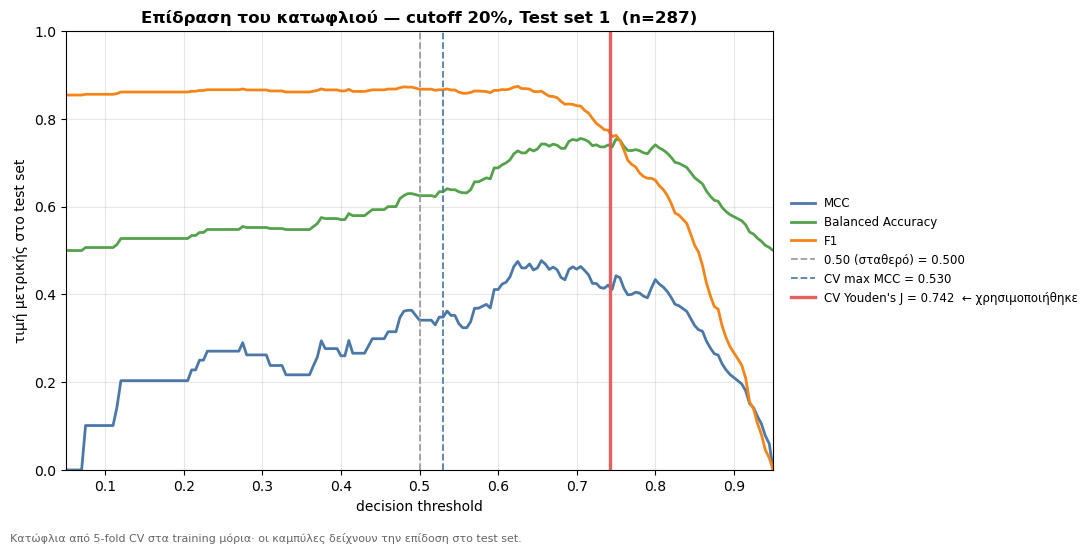

In [16]:
# ====== ΕΠΙΔΡΑΣΗ ΤΟΥ ΚΑΤΩΦΛΙΟΥ — μόνο για το τρέχον σενάριο ======
# Χρησιμοποιεί ό,τι υπολόγισαν τα Βήματα 1 και 2 (label_case, test_set).
# Οι κάθετες γραμμές είναι κατώφλια που προκύπτουν ΜΟΝΟ από τα training (OOF)·
# οι καμπύλες δείχνουν πώς θα απέδιδε κάθε κατώφλι στο test set.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (matthews_corrcoef, balanced_accuracy_score, f1_score,
                             recall_score, roc_curve, confusion_matrix)

MAKE_PLOTS = True      # False αν το matplotlib του kernel κρασάρει
GRID = np.arange(0.05, 0.96, 0.005)

# --- OOF πιθανότητες από το Βήμα 1 (ή υπολογισμός, αν το κατώφλι ήταν σταθερό) ---
if globals().get('oof_train') is None:
    _cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    oof_train = np.mean([cross_val_predict(build(n), X_train, y_train, cv=_cv,
                                           method='predict_proba', n_jobs=1)[:, 1]
                         for n in members], axis=0)

# --- κατώφλια ανά κανόνα, από τα training δεδομένα ---
_fpr, _tpr, _t = roc_curve(y_train, oof_train)
rule_thr = {
    '0.50 (σταθερό)': 0.50,
    'CV max MCC':     float(GRID[int(np.argmax(
                          [matthews_corrcoef(y_train, (oof_train >= v).astype(int)) for v in GRID]))]),
    "CV Youden's J":  float(_t[np.argmax(_tpr - _fpr)]),
}

# --- πίνακας: κάθε κανόνας εφαρμοσμένος στο τρέχον test set ---
def _spec(y, p):
    tn, fp, _, _ = confusion_matrix(y, p, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) else np.nan

rows = []
for rule, thr in rule_thr.items():
    p = (proba >= thr).astype(int)
    rows.append({'Κανόνας': rule, 'Κατώφλι': round(thr, 3),
                 'Χρησιμοποιήθηκε': '✓' if abs(thr - threshold) < 1e-9 else '',
                 'MCC': matthews_corrcoef(y_test, p),
                 'Balanced Acc': balanced_accuracy_score(y_test, p),
                 'F1': f1_score(y_test, p, zero_division=0),
                 'Sensitivity': recall_score(y_test, p),
                 'Specificity': _spec(y_test, p)})
thr_effect = pd.DataFrame(rows)

_lab_short = label_case.replace('label_cutoff_', 'cutoff ')
print(f"=== Επίδραση κατωφλιού — {_lab_short}, {test_set} (n={len(y_test)}) ===")
print(thr_effect.round(3).to_string(index=False))

# ---------------------------------------------------------------- αποθήκευση
_name = f"threshold_effect_{label_case.replace(chr(37), '')}_{TEST_TAG}"
try:
    thr_effect.round(4).to_csv(f'{OUT}/{_name}.csv', index=False, encoding='utf-8-sig')
    print(f"\nΑποθηκεύτηκε: {OUT}/{_name}.csv")
except PermissionError:
    print(f"\n⚠ κλειδωμένο: {OUT}/{_name}.csv")

# ---------------------------------------------------------------- διάγραμμα
if MAKE_PLOTS:
    fig, ax = plt.subplots(figsize=(11, 5.5))

    for mn, fn_, col in [('MCC', matthews_corrcoef, '#4C78A8'),
                         ('Balanced Accuracy', balanced_accuracy_score, '#54A24B'),
                         ('F1', lambda a, b: f1_score(a, b, zero_division=0), '#F58518')]:
        ax.plot(GRID, [fn_(y_test, (proba >= v).astype(int)) for v in GRID],
                color=col, lw=2, label=mn)

    _style = {'0.50 (σταθερό)': '#999999', 'CV max MCC': '#4C78A8', "CV Youden's J": '#E45756'}
    for rule, thr in rule_thr.items():
        used = abs(thr - threshold) < 1e-9
        ax.axvline(thr, color=_style[rule], ls='-' if used else '--',
                   lw=2.4 if used else 1.3, alpha=0.95,
                   label=f"{rule} = {thr:.3f}" + ("  ← χρησιμοποιήθηκε" if used else ""))

    ax.set_xlim(0.05, 0.95); ax.set_ylim(0, 1)
    ax.set_xlabel('decision threshold')
    ax.set_ylabel('τιμή μετρικής στο test set')
    ax.set_title(f'Επίδραση του κατωφλιού — {_lab_short}, {test_set}  (n={len(y_test)})',
                 fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8.5, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.text(0.01, 0.005, 'Κατώφλια από 5-fold CV στα training μόρια· '
             'οι καμπύλες δείχνουν την επίδοση στο test set.',
             fontsize=8, color='#666666')
    fig.tight_layout(rect=[0, 0.03, 1, 1])

    try:
        fig.savefig(f'{OUT}/{_name}.png', dpi=200, bbox_inches='tight')
        print(f"Αποθηκεύτηκε: {OUT}/{_name}.png")
    except PermissionError:
        pass
    plt.show()
